# Walmart Mattress Market_v01

In [81]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [83]:
import os
import sys
import io
from io import BytesIO
import csv
import google.auth
from google.cloud import bigquery
#from google.cloud import bigquery_storage

In [85]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "../market-analysis-project-91130-9f9a036682b6.json"

credentials, project_id = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

bqclient = bigquery.Client(credentials=credentials, project=project_id,)

In [87]:
# get the Matttress data from BigQuery
sql = f"""
select * from vs_pb.stckln_wmt_ms_trend  
where bsr_ctgry_label='01. Mattresses'
"""

df_wm = bqclient.query(sql).to_dataframe()

In [88]:
print(df_wm)

       bsr_ctgry_label         Brand_raw         Brand_adj   RetailerSku  \
0       01. Mattresses  KODIAK FURNITURE  KODIAK FURNITURE     301441107   
1       01. Mattresses  KODIAK FURNITURE  KODIAK FURNITURE     301441107   
2       01. Mattresses  KODIAK FURNITURE  KODIAK FURNITURE  1VAOALLR9Y13   
3       01. Mattresses          BIZCHAIR          BIZCHAIR  18XPSX8ZFNQN   
4       01. Mattresses          BIZCHAIR          BIZCHAIR  18XPSX8ZFNQN   
...                ...               ...               ...           ...   
171563  01. Mattresses      LEMONTALKING      LEMONTALKING    3935757738   
171564  01. Mattresses      LEMONTALKING      LEMONTALKING    1276734883   
171565  01. Mattresses      LEMONTALKING      LEMONTALKING    5327613198   
171566  01. Mattresses         UNBRANDED         UNBRANDED   15173323425   
171567  01. Mattresses         UNBRANDED         UNBRANDED   14363655355   

                                                    Title  \
0       #6000 276 Coil Hin

### 1. 시장 점유율

In [91]:
df1=df_wm.copy()
df_zinus = df1[df1['Brand_adj'] == 'ZINUS'].copy()

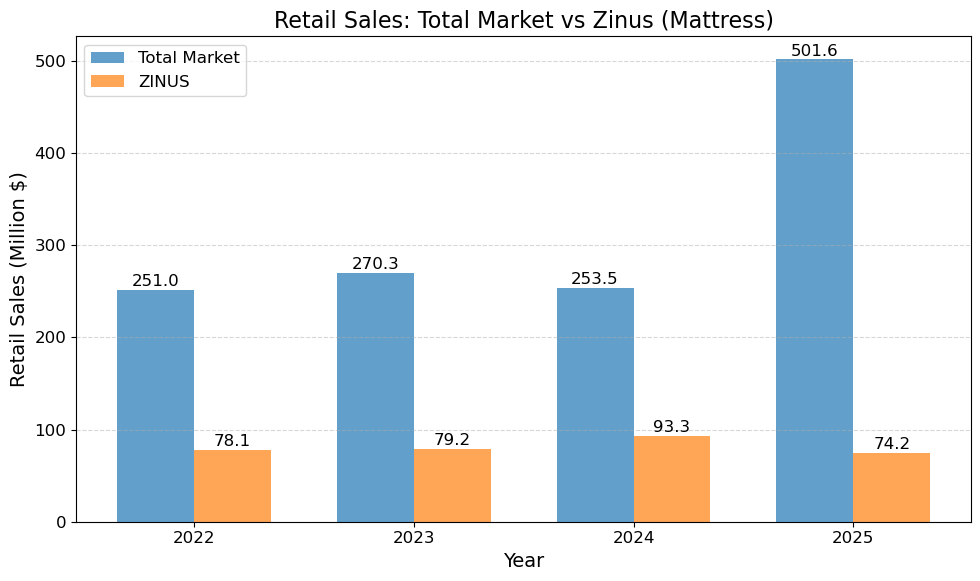

In [93]:
# ---------- 2. 연도별 매출 합계 ----------
total_sales = df1.groupby('year')['RetailSales'].sum().reset_index(name='TotalMarket')
zinus_sales = df_zinus.groupby('year')['RetailSales'].sum().reset_index(name='ZINUS')

# ---------- 3. 병합 ----------
merged = pd.merge(total_sales, zinus_sales, on='year', how='outer').fillna(0)

# ---------- 4. 전체 폰트 크기 설정 ----------
plt.rcParams.update({
    'font.size': 13,          # 기본 폰트 크기
    'axes.titlesize': 16,     # 제목
    'axes.labelsize': 14,     # 축 라벨
    'xtick.labelsize': 12,    # X축 눈금
    'ytick.labelsize': 12,    # Y축 눈금
    'legend.fontsize': 12     # 범례 폰트
})

# ---------- 4. 그래프 ----------
plt.figure(figsize=(10,6))
bar_width = 0.35
x = range(len(merged['year']))

bars1 = plt.bar([i - bar_width/2 for i in x], merged['TotalMarket']/1e6, 
                width=bar_width, label='Total Market', alpha=0.7)
bars2 = plt.bar([i + bar_width/2 for i in x], merged['ZINUS']/1e6, 
                width=bar_width, label='ZINUS', alpha=0.7)

# ---------- 5. 막대 위에 매출액 표시 ----------
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2, 
            height + 1, 
            f"{height:,.1f}",  # 소수점 1자리
            ha='center', va='bottom', fontsize=12
        )

add_labels(bars1)
add_labels(bars2)

# ---------- 6. 시각적 설정 ----------
plt.xticks(x, merged['year'])
plt.ylabel('Retail Sales (Million $)')
plt.xlabel('Year')
plt.title('Retail Sales: Total Market vs Zinus (Mattress)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

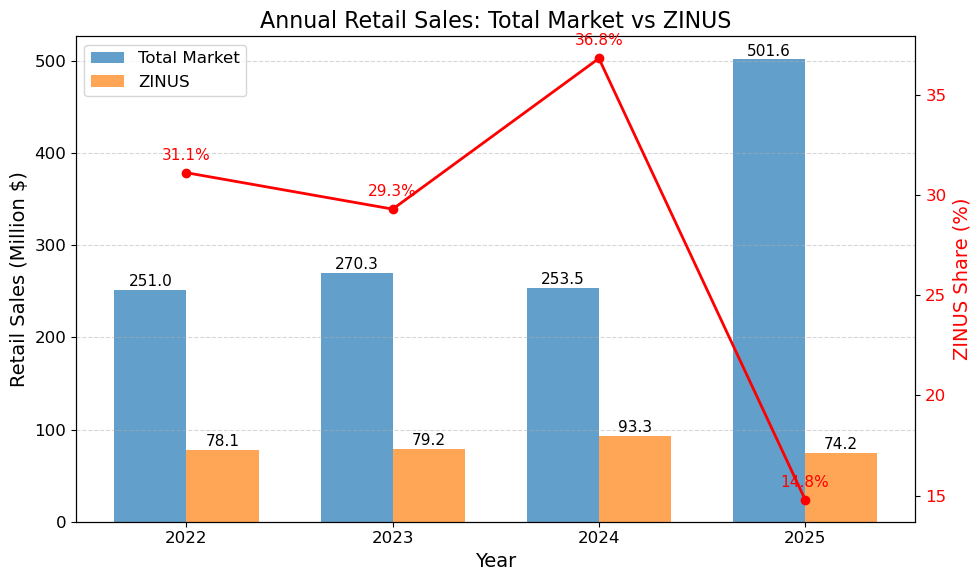

In [96]:
# ---------- 2. 연도별 매출 합계 ----------
total_sales = df1.groupby('year')['RetailSales'].sum().reset_index(name='TotalMarket')
zinus_sales = df_zinus.groupby('year')['RetailSales'].sum().reset_index(name='ZINUS')

# ---------- 3. 병합 ----------
merged = pd.merge(total_sales, zinus_sales, on='year', how='outer').fillna(0)

# ---------- 4. 비중(%) 계산 ----------
merged['ZINUS_share'] = (merged['ZINUS'] / merged['TotalMarket']) * 100

# ---------- 5. 폰트 설정 ----------
plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12
})

# ---------- 6. 그래프 ----------
fig, ax1 = plt.subplots(figsize=(10,6))
bar_width = 0.35
x = range(len(merged['year']))

# ─ Total & ZINUS 매출 (좌측 Y축)
bars1 = ax1.bar([i - bar_width/2 for i in x], merged['TotalMarket']/1e6, 
                width=bar_width, label='Total Market', alpha=0.7)
bars2 = ax1.bar([i + bar_width/2 for i in x], merged['ZINUS']/1e6, 
                width=bar_width, label='ZINUS', alpha=0.7)

ax1.set_ylabel('Retail Sales (Million $)')
ax1.set_xlabel('Year')
ax1.set_xticks(x)
ax1.set_xticklabels(merged['year'])
ax1.legend(loc='upper left')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# ─ 매출액 라벨
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width()/2, 
            height + 1, 
            f"{height:,.1f}", 
            ha='center', va='bottom', fontsize=11
        )

add_labels(bars1)
add_labels(bars2)

# ─ ZINUS 비중 (%) (우측 Y축)
ax2 = ax1.twinx()
ax2.plot(x, merged['ZINUS_share'], color='red', marker='o', linewidth=2, label='ZINUS Share (%)')
ax2.set_ylabel('ZINUS Share (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# ─ 각 점 위에 비중 표시
for i, val in enumerate(merged['ZINUS_share']):
    ax2.text(i, val + 0.5, f"{val:.1f}%", color='red', ha='center', va='bottom', fontsize=11)

plt.title('Annual Retail Sales: Total Market vs ZINUS')
fig.tight_layout()
plt.show()

In [98]:
# brand별 매출 합계 집계
brand_sales = (
    df1.groupby('Brand_adj')['RetailSales']
      .sum()
      .reset_index()
      .sort_values('RetailSales', ascending=False)
)

print(brand_sales.head(20))  # 매출 상위 20개 브랜드 출력

               Brand_adj   RetailSales
757                ZINUS  3.248029e+08
439         MLILY FAMILY  7.728434e+07
471             NAPQUEEN  6.486845e+07
495       NOVILLA FAMILY  5.054967e+07
225           FDW DIRECT  4.960238e+07
400            MAINSTAYS  4.317150e+07
602       SIMMONS FAMILY  3.393680e+07
386         LUCID FAMILY  3.332238e+07
483               NISIEN  2.815640e+07
275               GUUKIN  1.958996e+07
690            UNBRANDED  1.891099e+07
22              ALLSWELL  1.790824e+07
51             BABO CARE  1.764331e+07
348                  KOW  1.724209e+07
264            GRANDREST  1.604656e+07
144             COOL GEL  1.578693e+07
186  DREAM SOLUTIONS USA  1.525920e+07
479           NEO DIRECT  1.499507e+07
396              MADINOG  1.461415e+07
652          SYNTHOSPACE  1.150657e+07


In [100]:
# 2. 연도-브랜드별 매출 집계
brand_year_sales = (
    df1.groupby(['year', 'Brand_adj'])['RetailSales']
       .sum()
       .reset_index()
)

# 3. 전체 매출 기준 Top 10 브랜드 추출
top10_brands = (
    brand_year_sales.groupby('Brand_adj')['RetailSales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# 4. Others 포함
brand_year_sales['brand_top'] = brand_year_sales['Brand_adj'].where(
    brand_year_sales['Brand_adj'].isin(top10_brands), 'Others'
)

# 5. 연도별 매출 (Top10 + Others)
brand_year_sales_top10 = (
    brand_year_sales.groupby(['year', 'brand_top'])['RetailSales']
    .sum()
    .reset_index()
)

# 6. 피벗 (년도 x 브랜드 매출)
pivot_top10 = (
    brand_year_sales_top10
    .pivot(index='year', columns='brand_top', values='RetailSales')
    .fillna(0)
)

# 7. 연도별 비중(%) 추가
pivot_share = pivot_top10.div(pivot_top10.sum(axis=1), axis=0) * 100

# 보기 좋게 소수점 1자리까지 표시
pivot_share = pivot_share.round(1)

# 8. 결과 출력
print("=== 연도별 매출 (단위: USD) ===")
print(pivot_top10)
print("\n=== 연도별 브랜드 비중 (%) ===")
print(pivot_share)

=== 연도별 매출 (단위: USD) ===
brand_top   FDW DIRECT       GUUKIN  LUCID FAMILY    MAINSTAYS  MLILY FAMILY  \
year                                                                           
2022         294808.51         0.00    7537410.93   2994415.96    3790910.42   
2023        2829822.68         0.00   12565165.42  14403997.18   10567561.36   
2024        4607658.39     48809.69   12607528.61  10204401.38    8206434.57   
2025       41870093.08  19541149.57     612275.83  15568685.61   54719437.80   

brand_top     NAPQUEEN       NISIEN  NOVILLA FAMILY        Others  \
year                                                                
2022        3559155.91     95474.30     12840610.23  1.322714e+08   
2023       13162142.44   1091461.71      8457351.37  1.174077e+08   
2024        7327842.44   3644837.21      6535091.93  9.857818e+07   
2025       40819310.86  23324626.98     22716618.51  2.029127e+08   

brand_top  SIMMONS FAMILY        ZINUS  
year                                  

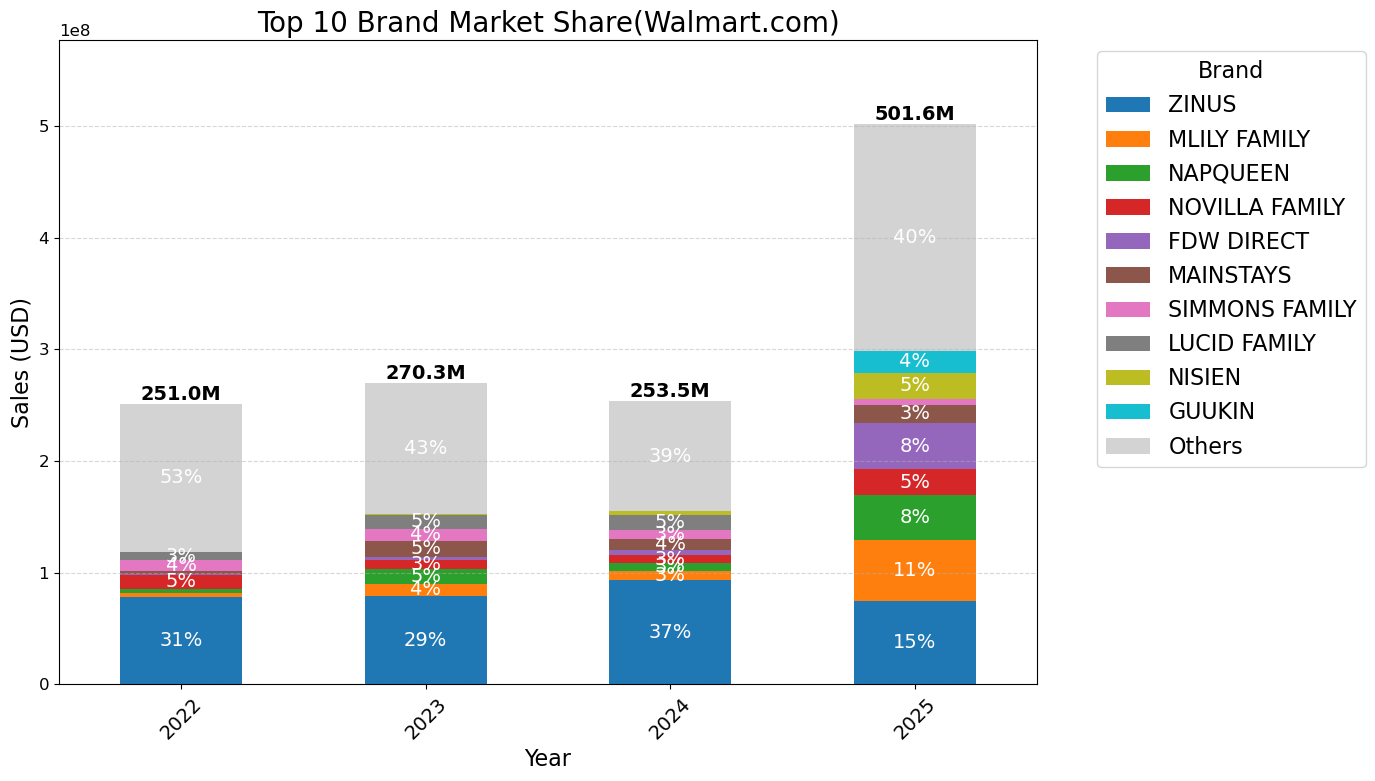

In [102]:
# 6-1. 브랜드별 총매출 합계 기준 내림차순
brand_totals = pivot_top10.sum(axis=0).sort_values(ascending=False)

# 6-2. Others를 맨 위로
if "Others" in brand_totals.index:
    brand_order = brand_totals.drop("Others").index.tolist() + ["Others"]
else:
    brand_order = brand_totals.index.tolist()

pivot_top10 = pivot_top10[brand_order]

# 7. 색상 지정 (Others = 회색)
colors = plt.cm.tab10.colors  # 기본 colormap에서 10개 색상
brand_colors = {b: colors[i % len(colors)] for i, b in enumerate(brand_order)}
if "Others" in brand_colors:
    brand_colors["Others"] = "lightgrey"

# 8. 누적 막대그래프
ax = pivot_top10.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 8),
    color=[brand_colors[b] for b in pivot_top10.columns]
)

plt.title("Top 10 Brand Market Share(Walmart.com)", fontsize=20)
plt.xlabel("Year", fontsize=16)
plt.ylabel("Sales (USD)", fontsize=16)
plt.xticks(rotation=45, fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# ✅ 범례 표시 (Others 포함)
plt.legend(title="Brand", bbox_to_anchor=(1.05, 1), loc='upper left', 
           fontsize=16, title_fontsize=16)

# ---------- 여기부터 추가: 비중(%) + 상단 총매출(M) 표기 ----------
# 연도(행)별 총매출
totals_per_year = pivot_top10.sum(axis=1)

# 상단 라벨이 잘 보이도록 여유공간 확보
ax.set_ylim(0, totals_per_year.max() * 1.15)

for i, idx in enumerate(pivot_top10.index):
    row = pivot_top10.loc[idx]
    total = totals_per_year.loc[idx]

    # 총매출이 0이면 스킵
    if total == 0:
        continue

    cum = 0.0
    for b in pivot_top10.columns:
        val = float(row[b]) if pd.notna(row[b]) else 0.0
        if val <= 0:
            continue

        share = val / total  # 비중 (0~1)
        y_center = cum + val / 2.0

        # 구간이 충분히 클 때는 구간 중앙에 흰색으로 %, 작으면 구간 위에 검정으로 표시
        if share >= 0.025:  # 6% 이상이면 내부에 표시
            ax.text(
                i, y_center, f"{share:.0%}",
                ha="center", va="center",
                fontsize=14, color="white"
            )
            
        cum += val

    # 막대 상단에 연도 총매출(Million) 라벨
    ax.text(
        i, total, f"{total/1_000_000:.1f}M",
        ha="center", va="bottom",
        fontsize=14, fontweight="bold"
    )
# ---------- 추가 끝 ----------

plt.tight_layout()
plt.show()